In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4329.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4223.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4253.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4190.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4354.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4136.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4226.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4214.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4888.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4170.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4323.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4262.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4788.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4657.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4387.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4255.jpg
/kaggle/

Question 1

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical
from tensorflow.image import resize
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential

In [ ]:
# Define your folder structure
data_dir = "/kaggle/input/cat-and-dog/training_set/training_set"
classes = ['cats', 'dogs']

#Dataset source: https://www.kaggle.com/datasets/tongpython/cat-and-dog?resource=download-directory

In [ ]:
# Load and preprocess image data
def load_and_preprocess_data(data_dir, classes, target_shape=(224, 224)):
    data = []
    labels = []

    for i, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name) #'/content/drive/MyDrive/dataset/cats/
        for filename in os.listdir(class_dir):         #['cat1.jpg', 'cat2.jpg', ...]
            if filename.endswith('.jpg'):
                file_path = os.path.join(class_dir, filename)
                # Load and preprocess the image
                img = load_img(file_path, target_size=target_shape)
                img_array = img_to_array(img)
                data.append(img_array)
                labels.append(i)

    return np.array(data), np.array(labels)

# Split data into training and testing sets
data, labels = load_and_preprocess_data(data_dir, classes)
labels = to_categorical(labels, num_classes=len(classes))  # Convert labels to one-hot encoding
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)


In [ ]:

# Number of classes in your dataset
num_classes = len(classes)   # or set explicitly, e.g. num_classes = 10

# VGG-19 Sequential Model
model = Sequential()

# -------------------
# Input layer + Block 1
# -------------------
# Input: 224 x 224 x 3
model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), strides=(2, 2)))

# -------------------
# Block 2: 2 x 128 filters
# -------------------
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), strides=(2, 2)))

# -------------------
# Block 3: 4 x 256 filters
# -------------------
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), strides=(2, 2)))

# -------------------
# Block 4: 4 x 512 filters
# -------------------
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), strides=(2, 2)))

# -------------------
# Block 5: 4 x 512 filters
# -------------------
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), strides=(2, 2)))

# -------------------
# Flatten + Fully Connected layers
# -------------------
model.add(Flatten())

# Two FC layers with 4096 neurons each
model.add(Dense(4096, activation='relu'))
model.add(Dense(4096, activation='relu'))

# Output layer with softmax
model.add(Dense(num_classes, activation='softmax'))

# -------------------
# Compile the model
# -------------------
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Show model summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,19

 Total params: 139,578,434 (532.45 MB)

 Trainable params: 139,578,434 (532.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model and store the training history
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# Save model
model.save("image_classification_vgg19_cats_dogs.h5")



Epoch 1/20


I0000 00:00:1765544096.021541    1680 service.cc:148] XLA service 0x7b7b900234f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765544096.022382    1680 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765544096.022408    1680 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765544096.928805    1680 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1765544137.816425    1680 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


201/201 ━━━━━━━━━━━━━━━━━━━━ 218s 843ms/step - accuracy: 0.5051 - loss: 323.4038 - val_accuracy: 0.4884 - val_loss: 0.6937
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 137s 679ms/step - accuracy: 0.4906 - loss: 0.6938 - val_accuracy: 0.4884 - val_loss: 0.6940
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 136s 678ms/step - accuracy: 0.4988 - loss: 0.6935 - val_accuracy: 0.4884 - val_loss: 0.6937
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 137s 682ms/step - accuracy: 0.4985 - loss: 0.6933 - val_accuracy: 0.4884 - val_loss: 0.6934
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 137s 682ms/step - accuracy: 0.4857 - loss: 0.6934 - val_accuracy: 0.4884 - val_loss: 0.6935
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 137s 680ms/step - accuracy: 0.5080 - loss: 0.6931 - val_accuracy: 0.4884 - val_loss: 0.6933
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 137s 680ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.4884 - val_loss: 0.6936
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 136s 679ms/step - accuracy: 0.5078 - loss: 0.

Test accuracy: 0.4884


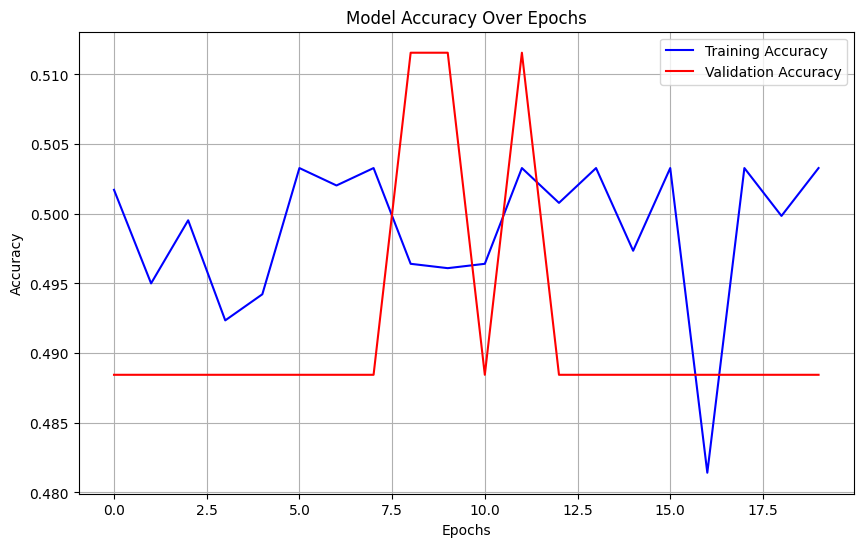

In [ ]:
import matplotlib.pyplot as plt

# Plot the accuracy graph
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

VGG19

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.utils import to_categorical
from tensorflow.image import resize
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import load_img, img_to_array


In [ ]:
import kagglehub
import os
import numpy as np

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical
from tensorflow.image import resize
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import load_img, img_to_array


In [ ]:
DATA_ROOT = "/kaggle/input/chest-xray-pneumonia/chest_xray"

data_dir = os.path.join(DATA_ROOT, "chest_xray", "train")
classes = ["NORMAL", "PNEUMONIA"]

In [ ]:
# Load and preprocess image data
def load_and_preprocess_data(data_dir, classes, target_shape=(224, 224)):
    data = []
    labels = []

    for i, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        for filename in os.listdir(class_dir):
            # Chest X-ray images are mostly .jpeg
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                file_path = os.path.join(class_dir, filename)
                # Load and preprocess the image
                img = load_img(file_path, target_size=target_shape)
                img_array = img_to_array(img)
                data.append(img_array)
                labels.append(i)

    return np.array(data), np.array(labels)
# Split data into training and testing sets
data, labels = load_and_preprocess_data(data_dir, classes)
labels = to_categorical(labels, num_classes=len(classes))  # Convert labels to one-hot encoding
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

In [ ]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

# Correct fixed input shape for pretrained VGG19
input_shape = (224, 224, 3)

# Load pretrained VGG19 without the top classifier
vgg19_base = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)

# Freeze base model
vgg19_base.trainable = False

# Add custom classification layers
x = Flatten()(vgg19_base.output)
x = Dense(64, activation='relu')(x)
output_layer = Dense(len(classes), activation='softmax')(x)

model = Model(inputs=vgg19_base.input, outputs=output_layer)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


I0000 00:00:1765538460.695722      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765538460.696403      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           13

 Total params: 21,630,210 (82.51 MB)

 Trainable params: 1,605,826 (6.13 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Evaluate the model on the test set
test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {test_accuracy[1]}')


# Save the model
save_path = "/kaggle/working/vgg19_classification_model.h5"
model.save(save_path)
print("Saved to:", save_path)

Epoch 1/20


I0000 00:00:1765538622.180260     199 service.cc:148] XLA service 0x7d2d74108410 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765538622.181077     199 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765538622.181101     199 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765538622.635261     199 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1765538634.195679     199 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


131/131 ━━━━━━━━━━━━━━━━━━━━ 70s 436ms/step - accuracy: 0.9117 - loss: 4.3815 - val_accuracy: 0.9770 - val_loss: 0.5221
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 41s 316ms/step - accuracy: 0.9899 - loss: 0.1437 - val_accuracy: 0.9722 - val_loss: 0.6368
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 302ms/step - accuracy: 0.9884 - loss: 0.0937 - val_accuracy: 0.9856 - val_loss: 0.1933
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 307ms/step - accuracy: 0.9949 - loss: 0.0342 - val_accuracy: 0.9837 - val_loss: 0.2191
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 304ms/step - accuracy: 0.9946 - loss: 0.0348 - val_accuracy: 0.9828 - val_loss: 0.2483
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 305ms/step - accuracy: 0.9930 - loss: 0.0870 - val_accuracy: 0.9837 - val_loss: 0.3573
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 305ms/step - accuracy: 0.9897 - loss: 0.1325 - val_accuracy: 0.9732 - val_loss: 0.4807
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 305ms/step - accuracy: 0.9962 - loss: 0.0412 - val

Test accuracy: 0.9894636273384094
Saved to: /kaggle/working/vgg19_classification_model.h5


33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 250ms/step
Accuracy : 0.9895
Precision: 0.9895
Recall   : 0.9895
F1-score : 0.9894

Classification report:
              precision    recall  f1-score   support

      NORMAL       0.99      0.97      0.98       287
   PNEUMONIA       0.99      1.00      0.99       757

    accuracy                           0.99      1044
   macro avg       0.99      0.98      0.99      1044
weighted avg       0.99      0.99      0.99      1044



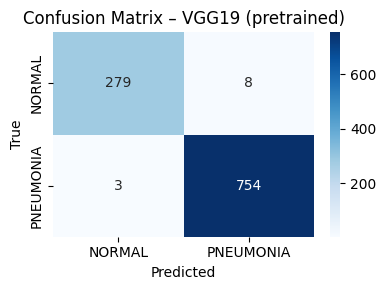

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ---- Get predictions on test set ----
y_prob = model.predict(X_test)               # shape (N, num_classes)
y_pred = np.argmax(y_prob, axis=1)           # predicted class indices
y_true = np.argmax(y_test, axis=1)           # true class indices

# ---- Basic metrics ----
acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'      # or 'macro'
)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# ---- Detailed per-class report ----
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=classes))

# ---- Confusion matrix ----
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – VGG19 (pretrained)')
plt.tight_layout()
plt.show()


ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.optimizers import Adam

# Correct fixed input shape for pretrained VGG19
input_shape = (224, 224, 3)

# Load pretrained ResNet50 without the top classifier
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)

# Freeze base model
resnet_base.trainable = False

# Add custom classification layers
x = Flatten()(resnet_base.output)
x = Dense(64, activation='relu')(x)
output_layer = Dense(len(classes), activation='softmax')(x)

model = Model(inputs=resnet_base.input, outputs=output_layer)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 30,010,434 (114.48 MB)

 Trainable params: 6,422,722 (24.50 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Evaluate the model on the test set
test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {test_accuracy[1]}')

# Save the model
save_path = "/kaggle/working/resnet50_classification_model.h5"
model.save(save_path)
print("Saved to:", save_path)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 36s 194ms/step - accuracy: 0.8993 - loss: 5.6777 - val_accuracy: 0.9780 - val_loss: 0.3347
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step - accuracy: 0.9836 - loss: 0.2733 - val_accuracy: 0.9751 - val_loss: 0.5064
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - accuracy: 0.9943 - loss: 0.0458 - val_accuracy: 0.9550 - val_loss: 1.0750
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - accuracy: 0.9909 - loss: 0.1198 - val_accuracy: 0.9828 - val_loss: 0.2973
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - accuracy: 0.9944 - loss: 0.0747 - val_accuracy: 0.9837 - val_loss: 0.3389
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - accuracy: 0.9980 - loss: 0.0086 - val_accuracy: 0.9847 - val_loss: 0.2916
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 119ms/step - accuracy: 1.0000 - loss: 7.9388e-06 - val_accuracy: 0.9856 - val_loss: 0.2982
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - accuracy: 1.0000 - los

Test accuracy: 0.984674334526062
Saved to: /kaggle/working/resnet50_classification_model.h5


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 208ms/step
Accuracy : 0.9847
Precision: 0.9847
Recall   : 0.9847
F1-score : 0.9847

Classification report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.98      0.97       287
   PNEUMONIA       0.99      0.99      0.99       757

    accuracy                           0.98      1044
   macro avg       0.98      0.98      0.98      1044
weighted avg       0.98      0.98      0.98      1044



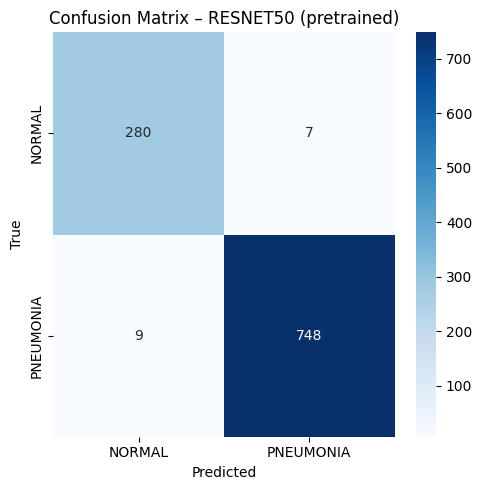

In [ ]:
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)           # predicted
y_true = np.argmax(y_test, axis=1)           # true

# ---- Basic metrics ----
acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# detailed report
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=classes))

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – RESNET50 (pretrained)')
plt.tight_layout()
plt.show()


InceptionV3

In [ ]:
# Load and preprocess image data
def load_and_preprocess_data(data_dir, classes, target_shape=(299, 299)):
    data = []
    labels = []

    for i, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        for filename in os.listdir(class_dir):
            # Chest X-ray images are mostly .jpeg
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                file_path = os.path.join(class_dir, filename)
                # Load and preprocess the image
                img = load_img(file_path, target_size=target_shape)
                img_array = img_to_array(img)
                data.append(img_array)
                labels.append(i)

    return np.array(data), np.array(labels)
# Split data into training and testing sets
data, labels = load_and_preprocess_data(data_dir, classes)
labels = to_categorical(labels, num_classes=len(classes))  # Convert labels to one-hot encoding
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

NameError: name 'data_dir' is not defined

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam

# Correct fixed input shape for pretrained VGG19
input_shape = (299, 299, 3)

# Load pretrained InceptionV3 without the top classifier
inception_base = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)

# Freeze base model
inception_base.trainable = False

# Add custom classification layers
x = GlobalAveragePooling2D()(inception_base.output)
x = Dense(64, activation='relu')(x)
output_layer = Dense(len(classes), activation='softmax')(x)

model = Model(inputs=inception_base.input, outputs=output_layer)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


I0000 00:00:1765533499.254106     298 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765533499.254769     298 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 21,934,050 (83.67 MB)

 Trainable params: 131,266 (512.76 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Evaluate the model on the test set
test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {test_accuracy[1]}')

# Save the model
save_path = "/kaggle/working/inceptionv3_classification_model.h5"
model.save(save_path)
print("Saved to:", save_path)

Epoch 1/20


I0000 00:00:1765533519.839587     337 service.cc:148] XLA service 0x7fa5dc014340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765533519.841346     337 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765533519.841370     337 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765533521.708118     337 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/131 ━━━━━━━━━━━━━━━━━━━━ 39:54 18s/step - accuracy: 0.7188 - loss: 5.4856

I0000 00:00:1765533531.394183     337 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


131/131 ━━━━━━━━━━━━━━━━━━━━ 58s 307ms/step - accuracy: 0.7590 - loss: 7.4760 - val_accuracy: 0.8238 - val_loss: 0.9864
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 139ms/step - accuracy: 0.9074 - loss: 0.4199 - val_accuracy: 0.9397 - val_loss: 0.2437
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 19s 142ms/step - accuracy: 0.9120 - loss: 0.4088 - val_accuracy: 0.9425 - val_loss: 0.1945
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 19s 142ms/step - accuracy: 0.9352 - loss: 0.2433 - val_accuracy: 0.9368 - val_loss: 0.2548
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 140ms/step - accuracy: 0.9528 - loss: 0.1448 - val_accuracy: 0.9215 - val_loss: 0.2882
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 140ms/step - accuracy: 0.9234 - loss: 0.3267 - val_accuracy: 0.9416 - val_loss: 0.2050
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 140ms/step - accuracy: 0.9337 - loss: 0.2737 - val_accuracy: 0.8803 - val_loss: 0.5925
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 141ms/step - accuracy: 0.9120 - loss: 0.4092 - val

Test accuracy: 0.9683908224105835
Saved to: /kaggle/working/inceptionv3_classification_model.h5


In [ ]:
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 270ms/step
Accuracy : 0.9684
Precision: 0.9685
Recall   : 0.9684
F1-score : 0.9684

Classification report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.95      0.94       287
   PNEUMONIA       0.98      0.98      0.98       757

    accuracy                           0.97      1044
   macro avg       0.96      0.96      0.96      1044
weighted avg       0.97      0.97      0.97      1044



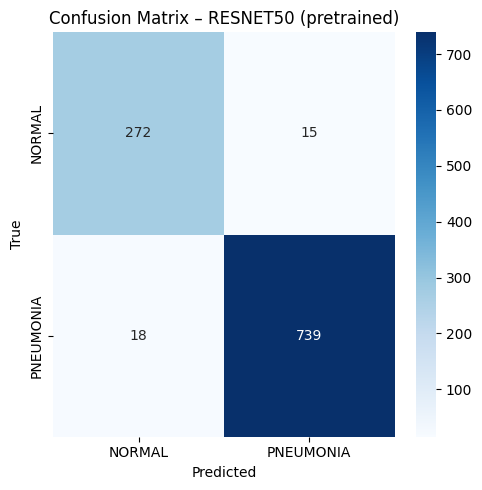

In [ ]:
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)           # predicted
y_true = np.argmax(y_test, axis=1)           # true

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – RESNET50 (pretrained)') # should be InceptionV3 actually
plt.tight_layout()
plt.show()

`ANALYSIS`

**FP = False Positive**

**FN = False Negative**

* `VGG19:`

accuracy: 0.989,
recall: 0.989

FP: 8, FN: 3 => total: 11 (lowest mistake)

* `ResNet50:`

accuracy: 0.984
recall: 0.984

FP: 7, FN: 9 => total: 16 (2nd lowest mistake)

* `InceptionV3:`

accuracy: 0.968,
recall: 0.968

FP: 15, FN: 18 => total: 33 (highest mistake)


### This makes the VGG19 model best among other models